In [1]:
suppressMessages({library("rwwa"); library("quantreg")})

# Quantile regression

In [2]:
gmst <- read.table("ts/gmst.txt", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2025]

# load the daily time series
ts <- read.csv("ts/UK001C_era5.csv", col.names = c("time", "tas"))
if (min(ts$tas) > 100) ts$tas <- ts$tas - 273.15

# add the year as a separate column so we can merge with the GMST
ts$year <- as.integer(substr(ts$time,1,4))
df <- merge(gmst, ts)

In [ ]:
# specify the quantiles you want to fit a trend through
qq <- c(0.005,0.01,0.02,0.03,0.05,seq(0.1,0.9,0.1),0.95,0.975,0.99,0.995)

# fit the quantile regression ('tau' is just the vector of quantiles)
qr_mdl <- rq(tas ~ gmst, data = df, tau = qq)
qr_pred <- predict(qr_mdl, newdata = gmst) # get fitted quantiles each year
rownames(qr_pred) <- gmst$year # label with year for easier matching later - to merge, make this into a new column instead

In [ ]:
dim(qr_pred)

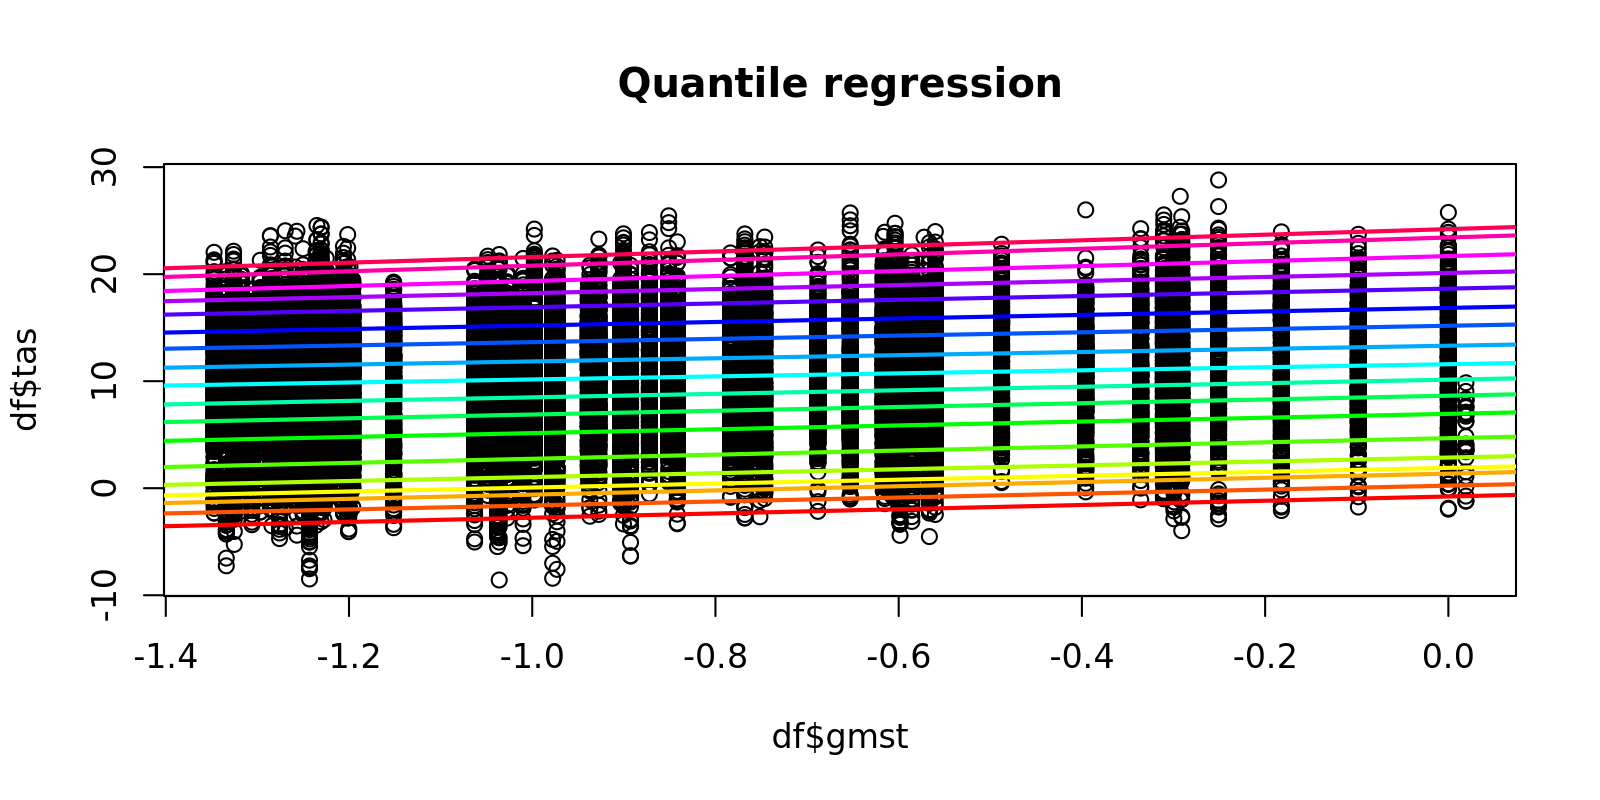

In [93]:
# plot the fitted quantiles
plot(df$gmst, df$tas, main = "Quantile regression")
matplot(gmst$gmst, qr_pred, add = T, type = "l", lty = 1, lwd = 2, col = rainbow(length(qq)))

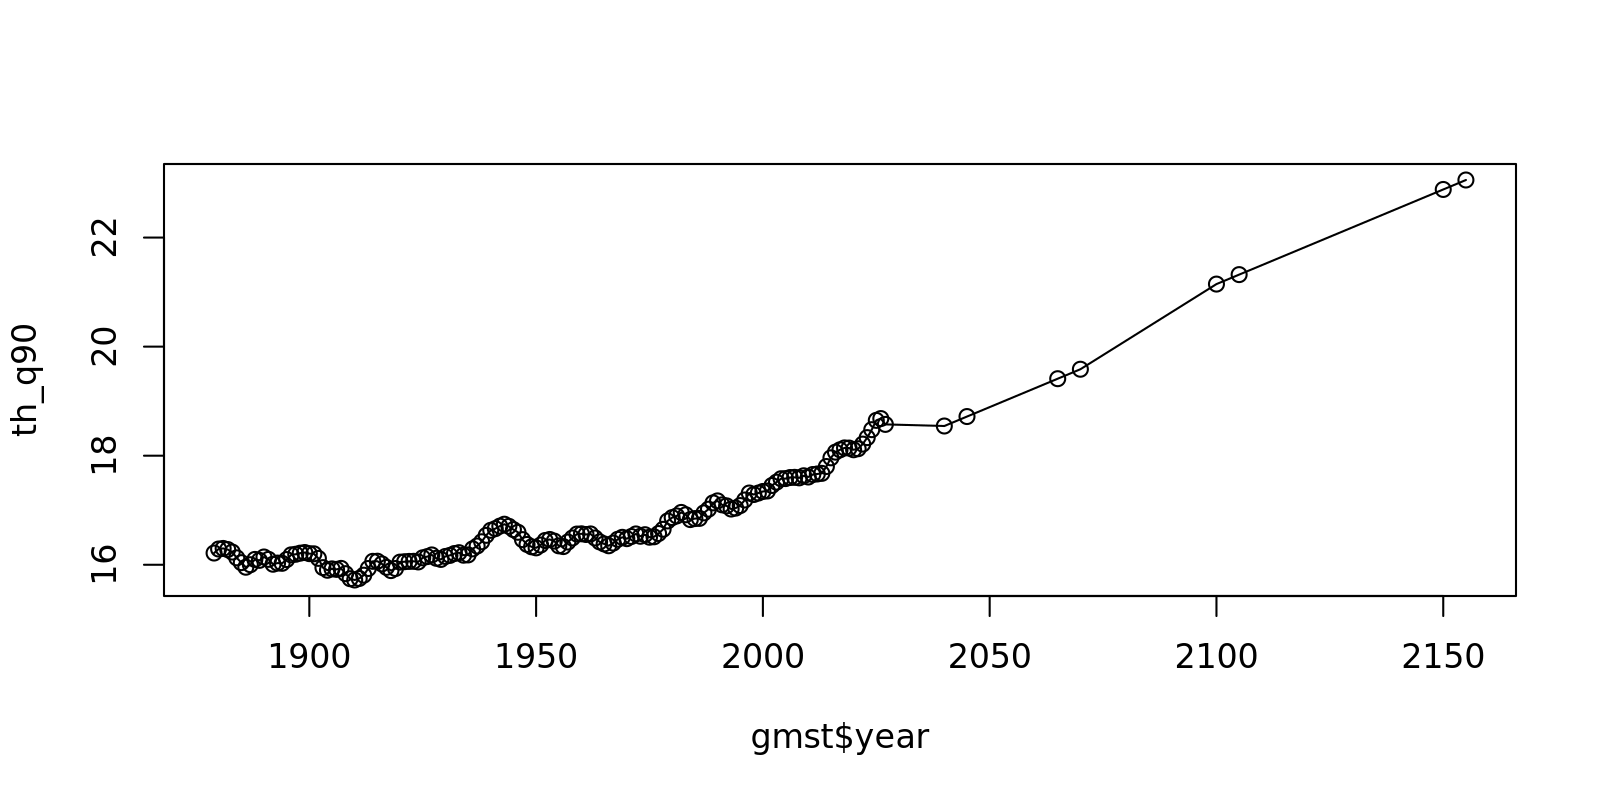

In [98]:
# extract your threshold value for each year
th_q90 <- qr_pred[,"tau= 0.900"]

plot(gmst$year, th_q90, type = "o")

# Joint distribution of two variables

In [180]:
# load covariate data
df <- merge(merge(merge(load_ts("ts/EA-drought_gmst-smoothed.dat", col.names = c("year", "gmst")),
                              load_ts("ts/EA-drought_detrended-nino-ond.dat", col.names = c("year", "nino_ond"))),
                        load_ts("ts/EA-drought_pr-24_cpc.dat", col.names = c("year", "pr"))),
                  load_ts("ts/EA-drought_pet-24_cpc.dat", col.names = c("year", "pet")))

ev_year = 2022

cov_2022 <- df[df$year == ev_year, "gmst", drop = F]
cov_cf <- cov_2022 - 1.2

In [181]:
# fit marginal distributions
mdl_pet <- fit_ns("norm", "shift", df, varnm = "pet", covnm = "gmst", lower = F, ev_year = ev_year)
mdl_pr <- fit_ns("norm_logt", "shift", df, varnm = "pr", covnm = "gmst", lower = T, ev_year = ev_year)

# fit joint model
mdl_joint <- fit_copula(mdl_pr, mdl_pet)

In [182]:
# estimate the marginal & join return periods
return_period(mdl_pet, mdl_pet$ev, fixed_cov = cov_2022)
return_period(mdl_pr, mdl_pr$ev, fixed_cov = cov_2022)
joint_returnperiod(mdl_joint, fixed_cov = cov_2022)

[1] 4.609511

[1] 21.52991

43 
34.91467

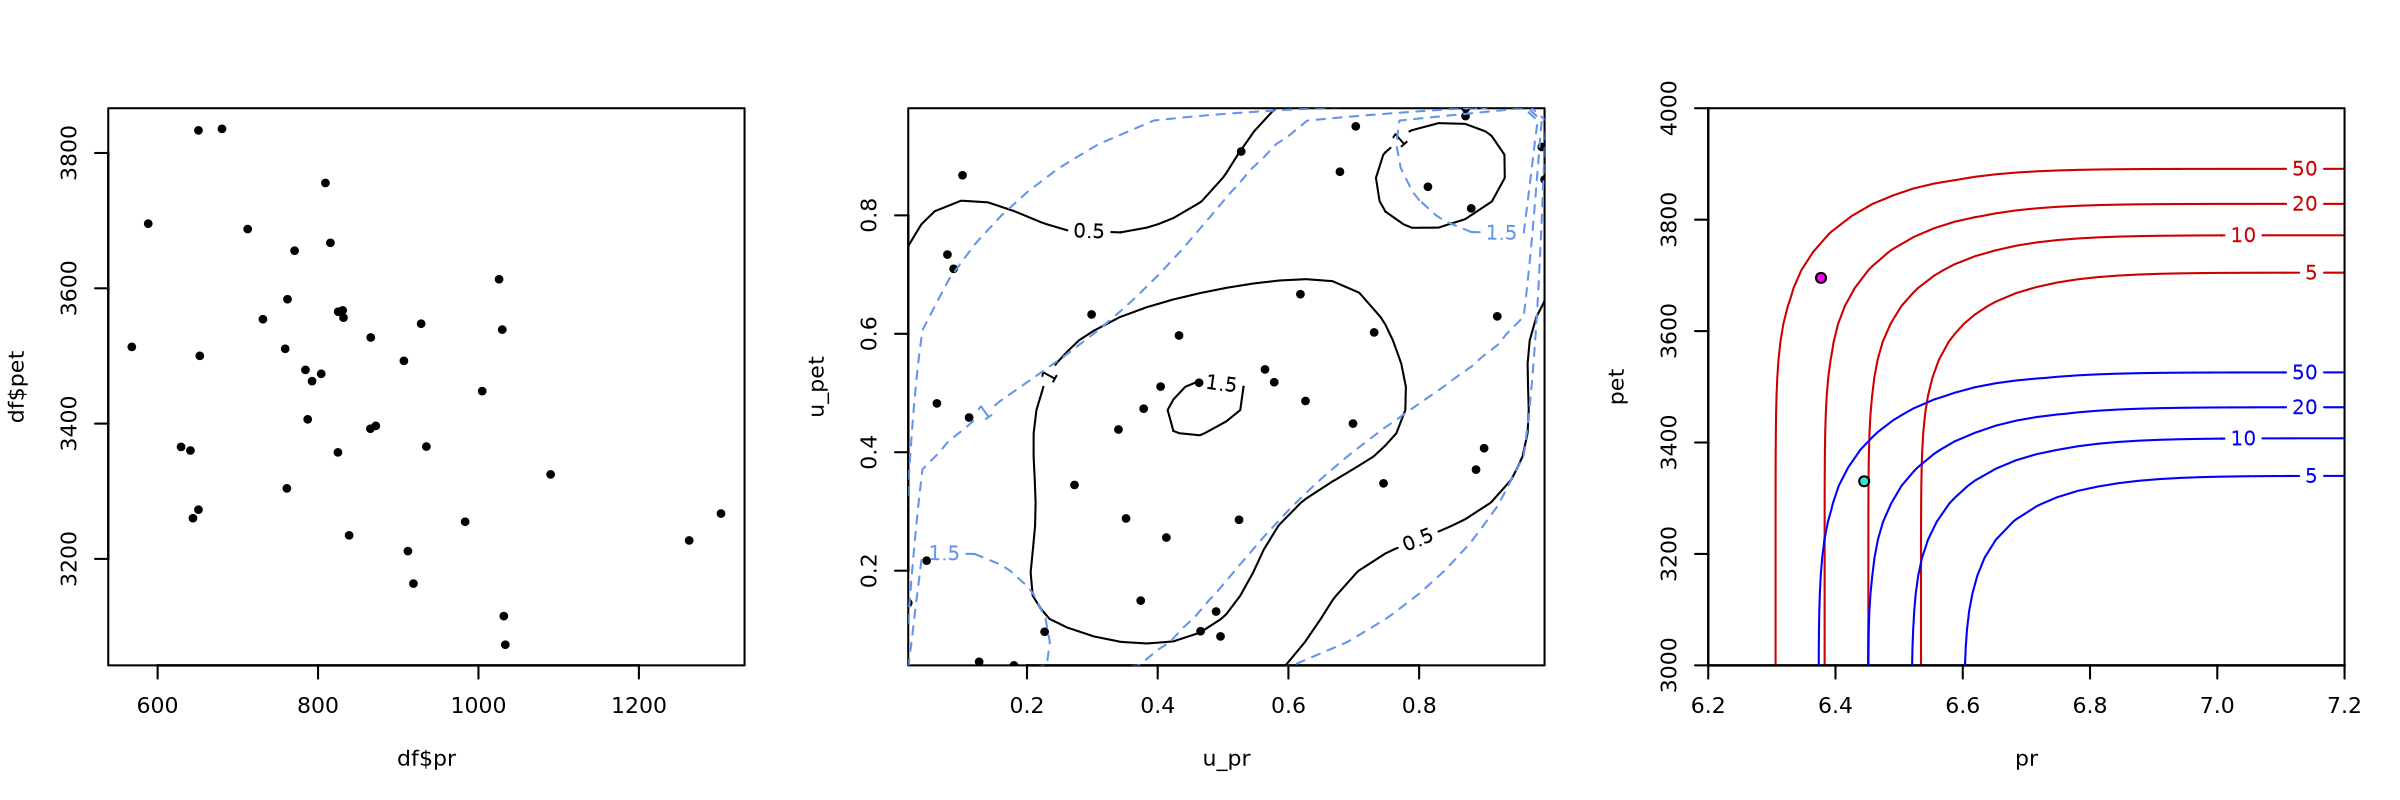

In [239]:
prep_window(c(1,3))

# plot the 
plot(df$pr, df$pet)

# plot the dependence structure, with fitted copula
plot_fitted_copula(mdl_joint)

# plot the return period contours - nb. this is showing log precip because we used a norm_logt fit type
plot_joint_contour(mdl_joint, fixed_cov = cov_2022, xlab = "pr", col = "red3", ylab = "pet")
plot_joint_contour(mdl_joint, fixed_cov = cov_cf, add = T, col = "blue")

plot_joint_event(mdl_joint, fixed_cov = cov_2022, pch = 21, bg = "magenta")
plot_joint_event(mdl_joint, fixed_cov = cov_cf, pch = 21, bg = "turquoise")

# Marginal & joint plots

(Mainly just for reference)

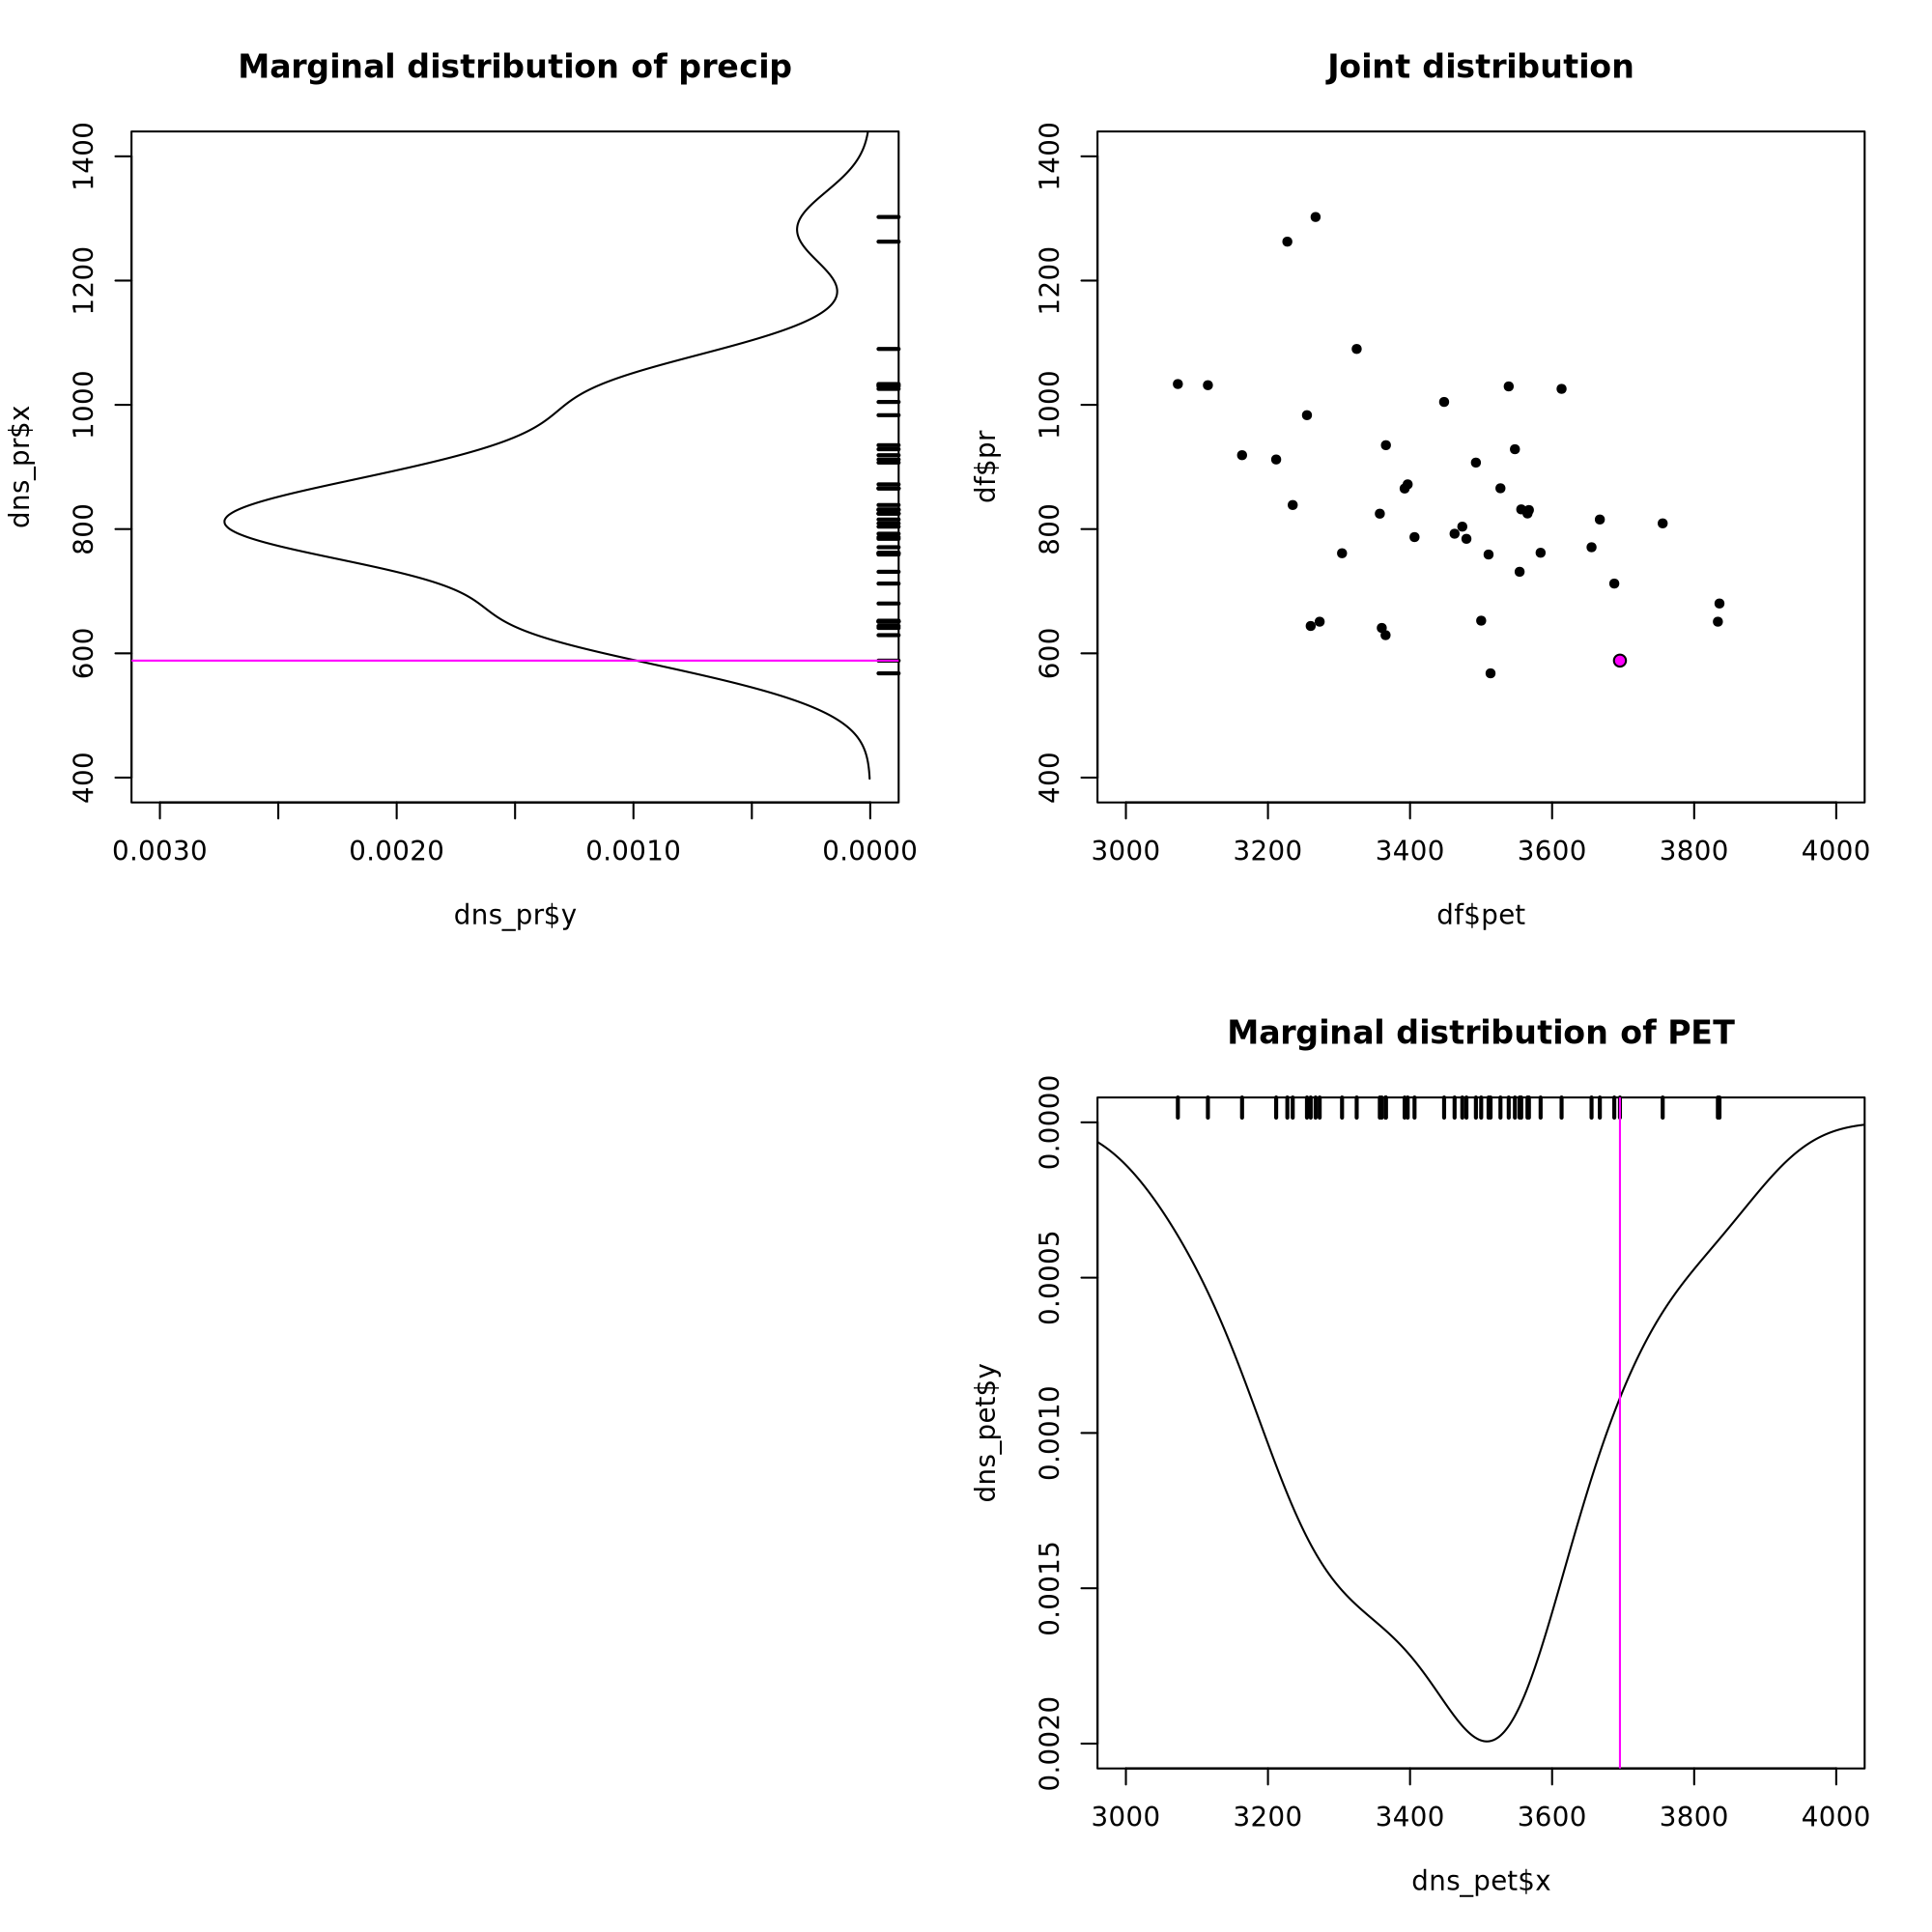

In [197]:
# kernel density estimates
dns_pr <- density(df$pr)
dns_pet <- density(df$pet)


# get the range of the data to make sure the axes line up
pr_lim <- range(pretty(df$pr))
pet_lim <- range(pretty(df$pet))

prep_window(c(2,2), h = 5, w = 5)

# marginal distribution of precip
plot(dns_pr$y, dns_pr$x, type = "l", xlim = rev(range(pretty(dns_pr$y))), ylim = pr_lim,  # flip the xlim axes to plot this on the RHS
     main = "Marginal distribution of precip")
rug(df$pr, side = 4, lwd = 2)
abline(h = df$pr[df$year == ev_year], col = "magenta")

# joint distribution of precip & pet
plot(df$pet, df$pr, xlim = pet_lim, ylim = pr_lim, main = "Joint distribution")
points(df[df$year == ev_year, c("pet", "pr")], pch = 21, bg = "magenta")

plot.new()

# marginal distribution of PET
plot(dns_pet$x, dns_pet$y, type = "l", xlim = pet_lim, ylim = rev(range(pretty(dns_pet$y))), # flip the xlim axes to plot this on the RHS
     main = "Marginal distribution of PET")
rug(df$pet, side = 3, lwd = 2)
abline(v = df$pet[df$year == ev_year], col = "magenta")



[1] 21.52991

[1] 4.609511

43 
34.91467

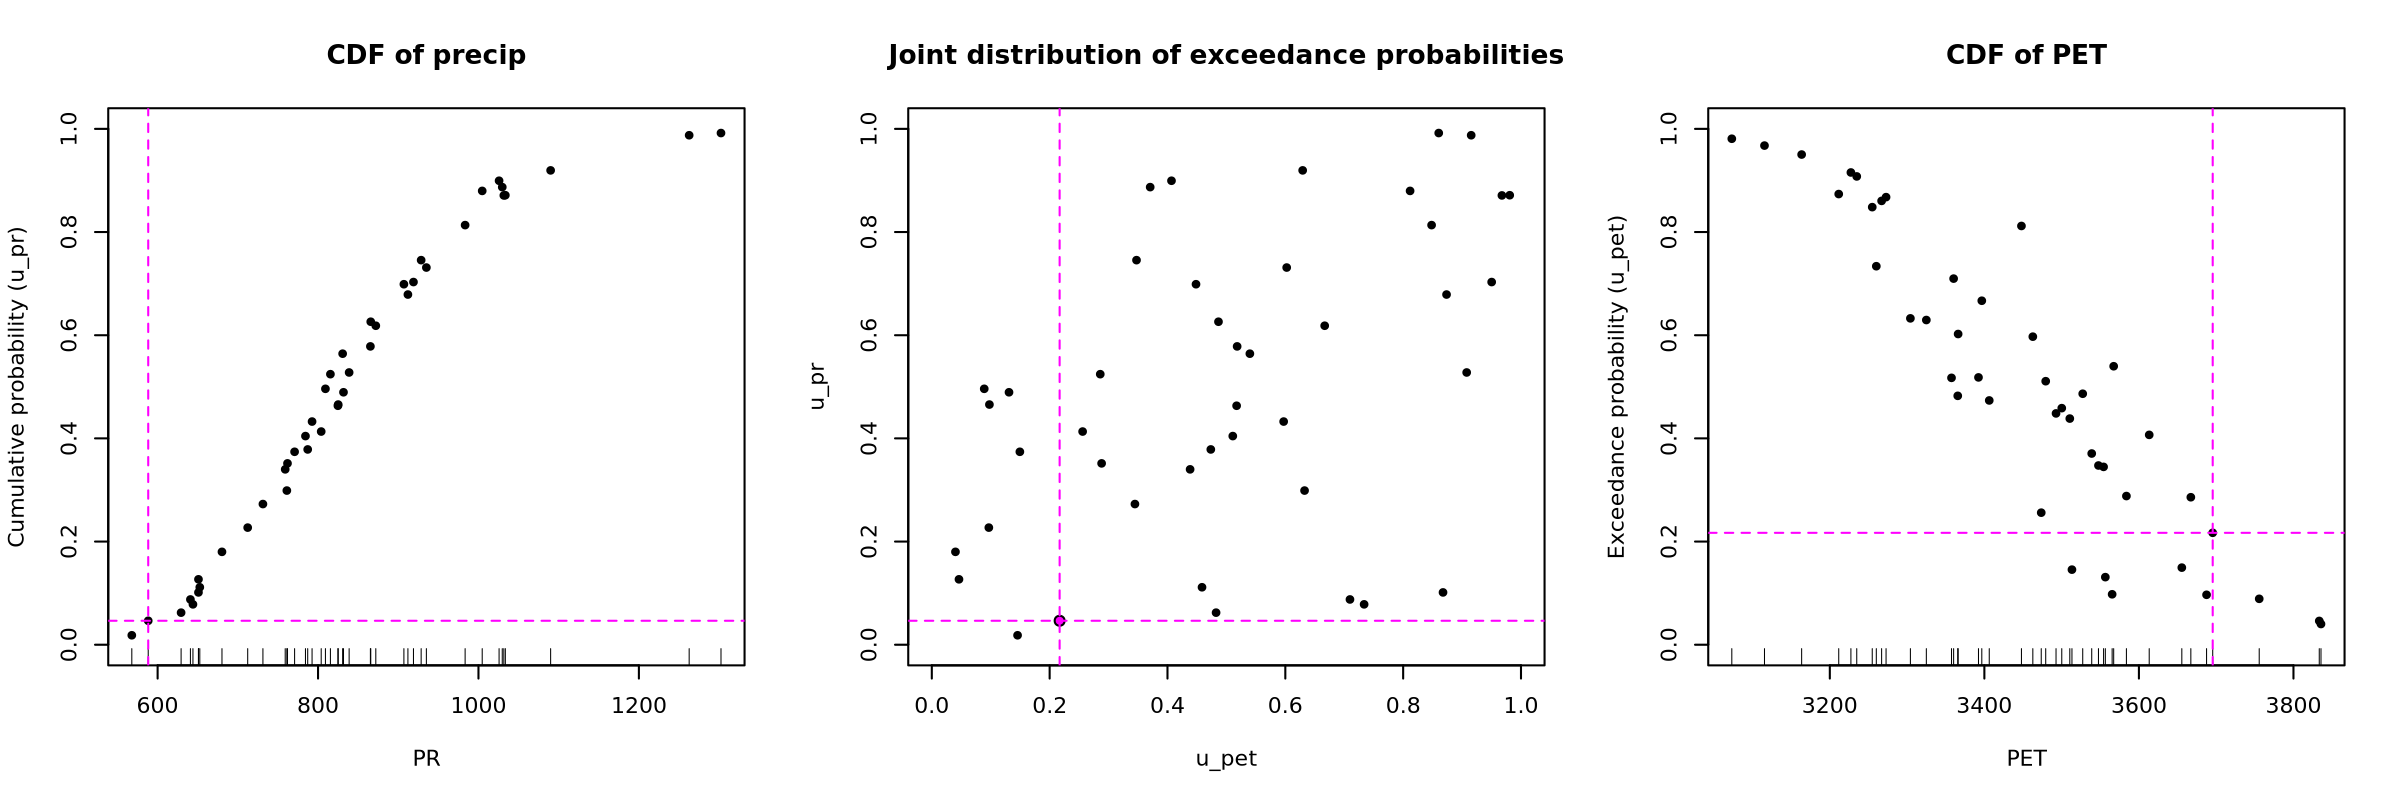

In [238]:
prep_window(c(1,3))

u_pr <- map_to_u(mdl_pr)
u_pet <- map_to_u(mdl_pet)

# CDF of PR - we're looking at low exceedances in this example, so the events on the right are more likely
plot(df$pr, u_pr, main = "CDF of precip", ylab = "Cumulative probability (u_pr)", xlab = "PR", ylim = c(0,1))
rug(df$pr)
abline(h = u_pr[df$year == ev_year], v = df[df$year == ev_year, "pr"], col = "magenta", lty = 2)

# joint distribution of exceedances
# this example was looking at low extremes in precip & high extremes in temperature, so the relationship goes in the other direction - more extreme events are in the bottom left corner
plot(u_pet, u_pr, xlim = c(0,1), ylim = c(0,1), xlab = "u_pet", ylab = "u_pr",
     main = "Joint distribution of exceedance probabilities")
points(u_pet[df$year == ev_year], u_pr[df$year == ev_year], pch = 21, bg = "magenta")
abline(h = u_pr[df$year == ev_year], v = u_pet[df$year == ev_year], col = "magenta", lty = 2)

plot_joint_contour(mdl_joint, fixed_cov = cov_2022, add = T, col = "red3")
plot_joint_contour(mdl_joint, fixed_cov = cov_cf, add = T, col = "blue")



# CDF of PET - we're looking at high exceedances in this example, so the events on the left are more likely
plot(df$pet, u_pet, main = "CDF of PET", ylab = "Exceedance probability (u_pet)", xlab = "PET", ylim = c(0,1))
rug(df$pet)
abline(h = u_pet[df$year == ev_year], v = df[df$year == ev_year, "pet"], col = "magenta", lty = 2)
